# Text Vectorization Practice

**목표**
1. `ratings.txt` 파일을 불러와 텍스트 데이터를 준비할 수 있다.
2. `Okt`를 사용해 한국어 형태소 기반 토큰 전처리를 수행할 수 있다.
3. `CountVectorizer`와 `TfidfVectorizer`로 문서 벡터를 생성할 수 있다.
4. `Word2Vec`과 `FastText`로 단어 임베딩을 학습하고 결과를 비교할 수 있다.

## 0. 실습 환경 준비

In [2]:
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from konlpy.tag import Okt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec, FastText

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_colwidth', 120)

okt = Okt()

## 1. 실제 리뷰 데이터 불러오기

1. `ratings.txt` 파일을 읽어 `df_raw` 데이터프레임을 생성하기
2. 구분자는 `	` 로 설정하기
3. 결측치를 제거하기
4. `document` 컬럼만 사용하여 `df` 데이터프레임을 만들기
5. 너무 오래 걸리지 않도록 무작위로 3000개 샘플을 추출하기
6. 인덱스를 재설정하기
7. 앞부분 5개 행을 확인하기

In [3]:
# ratings.txt 불러오기
df_raw = pd.read_table('ratings.txt')

# 결측치 제거
df_raw = df_raw.dropna()

display(df_raw)

# document 컬럼만 추출 후 3000개 무작위 샘플링
df = df_raw[['document']].sample(n=3000, random_state=42).reset_index(drop=True)

display(df.head(5))

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업이 부러웠는데. 사실 우리나라에서도 그 어려운시절에 끝까지 열정을 지킨 노라노 같은 전통이있어 저와 같은 사람들이 꿈을 꾸고...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1
...,...,...,...
199995,8963373,포켓 몬스터 짜가 ㅡㅡ;;,0
199996,3302770,쓰.레.기,0
199997,5458175,완전 사이코영화. 마지막은 더욱더 이 영화의질을 떨어트린다.,0
199998,6908648,왜난 재미없었지 ㅠㅠ 라따뚜이 보고나서 스머프 봐서 그런가 ㅋㅋ,0


,document
0,모피너무많이입고나와 불쾌함
1,결말이 ㅠ ㅠ 멜비푸포 완전멋져요 ㅠ이제서야알다니 ㅠㅠ
2,"타케모토 노보루 감독, 최고의 걸작이다"
3,진짜 인생 애니메이션 어릴땐 상상력자극으로 재밌고 커서는 우정간의 감동을 보며 재밌고
4,몇몇 맞지않는 전개도 있지만 이 정도면 훌륭하다. 우리 이순신장군님 영화도 이렇게 만드는 날이 왔으면 한다.


## 2. 리뷰 길이와 기본 분포 확인하기

1. 문자 수를 저장하는 `char_len` 컬럼 만들기
2. 공백 기준 단어 수를 저장하는 `word_space_len` 컬럼 만들기
3. 두 컬럼의 기술통계량 확인하기
4. `char_len` 분포를 히스토그램으로 시각화하기

,char_len,word_space_len
count,3000.000000,3000.000000
mean,35.035667,7.540000
std,29.246530,6.416551
min,1.000000,1.000000
25%,16.000000,3.000000
50%,27.000000,6.000000
75%,43.000000,9.000000
max,140.000000,38.000000


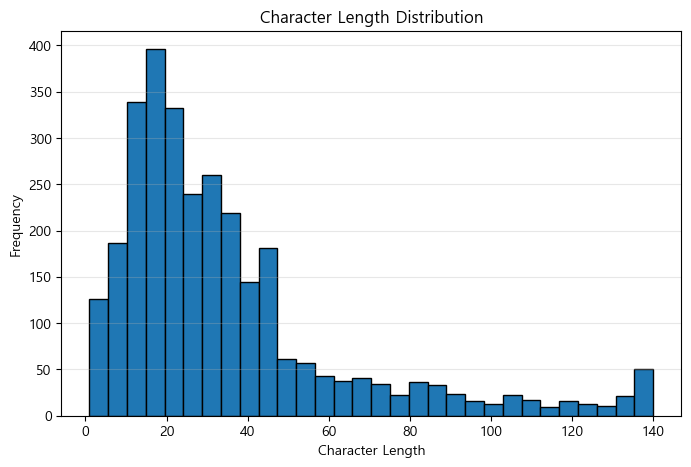

In [4]:
# 문자 수 컬럼 생성
df['char_len'] = df['document'].astype(str).str.len()

# 공백 기준 단어 수 컬럼 생성
df['word_space_len'] = df['document'].astype(str).str.split().str.len()

# 기술통계량 확인
display(df[['char_len', 'word_space_len']].describe())

# char_len 히스토그램
plt.figure(figsize=(8, 5))
plt.hist(df['char_len'], bins=30, edgecolor='black')

plt.title('Character Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 3. 정규표현식으로 리뷰 텍스트 정제하기

1. 한글과 공백만 남기고 나머지는 제거하는 `clean_text_fn()` 함수 만들기
2. 연속된 공백을 하나의 공백으로 정리하기
3. 양쪽 공백을 제거하기
4. 정제 결과를 저장하는 `clean_document` 컬럼 만들기
5. 원문과 정제문을 앞부분 5개 행으로 확인하기

In [5]:
# 여기에 코드를 작성하세요.
def clean_text_fn(text):
    text = str(text)                     # 문자열 변환
    text = re.sub(r'\s+', ' ', text)    # 여러 공백 -> 한 칸
    text = text.strip()                 # 앞뒤 공백 제거
    return text

df['clean_document'] = df['document'].apply(clean_text_fn)

display(df[['document', 'clean_document']].head(5))

,document,clean_document
0,모피너무많이입고나와 불쾌함,모피너무많이입고나와 불쾌함
1,결말이 ㅠ ㅠ 멜비푸포 완전멋져요 ㅠ이제서야알다니 ㅠㅠ,결말이 ㅠ ㅠ 멜비푸포 완전멋져요 ㅠ이제서야알다니 ㅠㅠ
2,"타케모토 노보루 감독, 최고의 걸작이다","타케모토 노보루 감독, 최고의 걸작이다"
3,진짜 인생 애니메이션 어릴땐 상상력자극으로 재밌고 커서는 우정간의 감동을 보며 재밌고,진짜 인생 애니메이션 어릴땐 상상력자극으로 재밌고 커서는 우정간의 감동을 보며 재밌고
4,몇몇 맞지않는 전개도 있지만 이 정도면 훌륭하다. 우리 이순신장군님 영화도 이렇게 만드는 날이 왔으면 한다.,몇몇 맞지않는 전개도 있지만 이 정도면 훌륭하다. 우리 이순신장군님 영화도 이렇게 만드는 날이 왔으면 한다.


## 4. Okt 기반 토큰 전처리 함수 만들기

1. 불용어 리스트 `ko_stopwords` 만들기
2. `Okt()` 객체를 사용해 형태소를 추출하기
3. `morphs(..., stem=True)`를 사용하기
4. 길이가 2 이상인 토큰만 남기기
5. 불용어를 제거하기
6. 토큰 리스트를 반환하는 `tokenize_ko_text()` 함수 만들기
7. 결과를 `tokens` 컬럼에 저장하기

In [6]:
ko_stopwords = [
    '은', '는', '이', '가', '을', '를', '에', '의', '도', '로', '과', '와',
    '에서', '에게', '께', '한테', '부터', '까지', '보다', '처럼', '만', '마다',
    '조차', '라도', '이나', '나', '든지', '든가',
    '그리고', '그러나', '하지만', '또한', '그래서', '즉', '또', '혹은', '또는',
    '및', '아니면', '그러면', '그런데',
    '이것', '그것', '저것', '이곳', '그곳', '저곳',
    '이런', '그런', '저런', '이렇게', '그렇게', '저렇게',
    '것', '수', '등', '때', '점', '중', '후', '전', '내', '외', '간',
    '하다', '되다', '있다', '없다', '같다', '않다', '보다', '말하다',
    '주다', '받다', '가다', '오다', '나다', '이다',
    '잘', '좀', '매우', '정말', '너무', '아주', '조금', '많이', '가장',
    '아', '어', '오', '음', '흠', '헉', '와', '오호', 'ㅋㅋ', 'ㅎㅎ', 'ㅠㅠ', 'ㅜㅜ',
    'the', 'a', 'an', 'is', 'are', 'was', 'were'
]

def tokenize_ko_text(text):
    # 형태소 분석 + 원형 복원
    tokens = okt.morphs(str(text), stem=True)

    # 불용어 제거 + 한 글자 제거
    tokens = [
        token for token in tokens
        if token not in ko_stopwords and len(token) > 1
    ]

    return tokens

# 토큰화 적용
df['tokens'] = df['clean_document'].apply(tokenize_ko_text)

# 결과 확인
display(df[['clean_document', 'tokens']].head(10))

,clean_document,tokens
0,모피너무많이입고나와 불쾌함,"[모피, 나오다, 불쾌하다]"
1,결말이 ㅠ ㅠ 멜비푸포 완전멋져요 ㅠ이제서야알다니 ㅠㅠ,"[결말, 메다, 푸다, 완전, 멋지다, 이제, 서다, 알다]"
2,"타케모토 노보루 감독, 최고의 걸작이다","[모토, 보루, 감독, 최고, 걸작]"
3,진짜 인생 애니메이션 어릴땐 상상력자극으로 재밌고 커서는 우정간의 감동을 보며 재밌고,"[진짜, 인생, 애니메이션, 어리다, 상상력, 자극, 으로, 재밌다, 커서, 우정, 감동, 재밌다]"
4,몇몇 맞지않는 전개도 있지만 이 정도면 훌륭하다. 우리 이순신장군님 영화도 이렇게 만드는 날이 왔으면 한다.,"[몇몇, 맞다, 전개도, 정도, 훌륭하다, 우리, 이순신장군, 영화, 만들다]"
5,번개치고 귀신튀어나오는 성궤나 불사의 영약 성배나 고대 중남미문명 외계인 개입설이나..뭔 차이가 있어서 이상하다 하는지 모르겠구만..ㅋ...하나님이나 예수가 아니라 외계인이 나와서 실망들하셨나?..ㅋ,"[번개, 치고, 귀신, 튀어나오다, 불사, 영약, 성배, 고대, 중남미, 문명, 외계인, 개입, .., 차이, 이상하다, 모르다, .., ..., 하나님, 예수, 아니다, 외계인, 나오다, 실망, ?..]"
6,우리나라 몇 안되는 진행 몰입도 좋은 영화중 하나. 2편이 기대되는데 안나올듯 하다. 류감독께 투자비만 더 지급되면 진짜 헐리우드급 영화가 탄생할 수 있을 듯.,"[우리나라, 안되다, 진행, 몰입도, 좋다, 영화, 하나, 편이, 기대, 나오다, 감독, 투자, 비만, 지급, 진짜, 헐리우드, 영화, 탄생]"
7,네러티브는 하나도 없는 예쁜 음악 동영상. 취미로 영화만드는 것은 이걸로 끝나길 . 잘하는 음악에 올인하길.,"[네러티브, 하나, 예쁘다, 음악, 동영상, 취미, 영화, 만들다, 끝나다, 음악, 올인]"
8,나이를 먹을수록 가슴깊이 느낄 수 있는 영화,"[나이, 먹다, 가슴, 깊이, 느끼다, 영화]"
9,진ㅉ ㅏ잼잇따!!!!!!!후끈후끈화끈화끈 액숀!!!!,"[잇다, 따다, !!!!!!!, 후끈, 후끈, 화끈화끈, 액숀, !!!!]"


## 5. 전처리 결과 점검하기

1. `token_len` 컬럼을 만들어 토큰 개수를 저장하기
2. 토큰이 3개 이상인 리뷰만 남긴 `df_tokens` 데이터프레임 만들기
3. `df_tokens`의 크기 확인하기
4. 원문, 정제문, 토큰 결과를 5개 행 확인하기
5. 가장 자주 등장한 토큰 20개를 구하기

In [7]:
# 토큰 개수 컬럼 생성
df['token_len'] = df['tokens'].apply(len)

# 토큰 3개 이상 데이터만 추출
df_tokens = df[df['token_len'] >= 3]

print(df_tokens.shape)

# 확인
display(df[['document', 'clean_document', 'tokens']].head(5))

# 전체 토큰 하나의 리스트로 합치기
all_tokens = sum(df['tokens'], [])

print(all_tokens)

# 단어 빈도수 계산
word_counter = Counter(all_tokens)

# 상위 20개 출력
print(word_counter.most_common(20))

(2613, 6)


,document,clean_document,tokens
0,모피너무많이입고나와 불쾌함,모피너무많이입고나와 불쾌함,"[모피, 나오다, 불쾌하다]"
1,결말이 ㅠ ㅠ 멜비푸포 완전멋져요 ㅠ이제서야알다니 ㅠㅠ,결말이 ㅠ ㅠ 멜비푸포 완전멋져요 ㅠ이제서야알다니 ㅠㅠ,"[결말, 메다, 푸다, 완전, 멋지다, 이제, 서다, 알다]"
2,"타케모토 노보루 감독, 최고의 걸작이다","타케모토 노보루 감독, 최고의 걸작이다","[모토, 보루, 감독, 최고, 걸작]"
3,진짜 인생 애니메이션 어릴땐 상상력자극으로 재밌고 커서는 우정간의 감동을 보며 재밌고,진짜 인생 애니메이션 어릴땐 상상력자극으로 재밌고 커서는 우정간의 감동을 보며 재밌고,"[진짜, 인생, 애니메이션, 어리다, 상상력, 자극, 으로, 재밌다, 커서, 우정, 감동, 재밌다]"
4,몇몇 맞지않는 전개도 있지만 이 정도면 훌륭하다. 우리 이순신장군님 영화도 이렇게 만드는 날이 왔으면 한다.,몇몇 맞지않는 전개도 있지만 이 정도면 훌륭하다. 우리 이순신장군님 영화도 이렇게 만드는 날이 왔으면 한다.,"[몇몇, 맞다, 전개도, 정도, 훌륭하다, 우리, 이순신장군, 영화, 만들다]"


['모피', '나오다', '불쾌하다', '결말', '메다', '푸다', '완전', '멋지다', '이제', '서다', '알다', '모토', '보루', '감독', '최고', '걸작', '진짜', '인생', '애니메이션', '어리다', '상상력', '자극', '으로', '재밌다', '커서', '우정', '감동', '재밌다', '몇몇', '맞다', '전개도', '정도', '훌륭하다', '우리', '이순신장군', '영화', '만들다', '번개', '치고', '귀신', '튀어나오다', '불사', '영약', '성배', '고대', '중남미', '문명', '외계인', '개입', '..', '차이', '이상하다', '모르다', '..', '...', '하나님', '예수', '아니다', '외계인', '나오다', '실망', '?..', '우리나라', '안되다', '진행', '몰입도', '좋다', '영화', '하나', '편이', '기대', '나오다', '감독', '투자', '비만', '지급', '진짜', '헐리우드', '영화', '탄생', '네러티브', '하나', '예쁘다', '음악', '동영상', '취미', '영화', '만들다', '끝나다', '음악', '올인', '나이', '먹다', '가슴', '깊이', '느끼다', '영화', '잇다', '따다', '!!!!!!!', '후끈', '후끈', '화끈화끈', '액숀', '!!!!', '차다', '어이없다', '슬래셔', '...', '갑자기', '빙의', '....', '?[-_=', '김꽃비', '한국', '배우다', '작품', '나오다', '뛰어나다', '..', '영화', '내용', '다르다', '드라마', '핵심', '집다', '좋다', '근데', '드라마', '시간', '짧다', '무미건조', '정도', '지나치다', '헛탕질', '하비에르', '바르뎀', '대단하다', '연기자', '인지', ',,', '삼류', '영화', '뭔가', '나오다', '...', '나오다', '...', '독수리', '타고', '어이없이', '끝

## 6. CountVectorizer로 BoW 문서-단어 행렬 만들기

1. 토큰 리스트를 공백으로 연결한 `token_text` 컬럼 만들기
2. `CountVectorizer(max_features=1000)` 객체 생성하기
3. `bow_matrix` 생성하기
4. vocabulary 크기 확인하기
5. 상위 15개 단어의 전체 출현 빈도를 구하기

In [30]:
# 1. 토큰 리스트를 공백으로 연결한 token_text 컬럼 만들기
df['token_text'] = df['tokens'].apply(lambda x: ' '.join(x))

# 2. CountVectorizer(max_features=1000) 객체 생성하기
cv = CountVectorizer(max_features=1000)

# 3. bow_matrix 생성하기
bow_matrix = cv.fit_transform(df['token_text'])

# 4. vocabulary 크기 확인하기
print("Vocabulary Size:", len(cv.vocabulary_))

# 5. 상위 15개 단어의 전체 출현 빈도 구하기
word_counts = np.asarray(bow_matrix.sum(axis=0)).flatten()

cv_vocab = cv.get_feature_names_out()

cv_freq_df = pd.DataFrame({
    'word': cv_vocab,
    'count': word_counts
}).sort_values(by='count', ascending=False)

print(cv_freq_df.head(15))

Vocabulary Size: 1000
    word  count
641   영화    995
826   좋다    245
784  재밌다    182
854   진짜    178
883   최고    151
550  아니다    151
632   연기    149
304  만들다    137
931   평점    136
688   으로    126
158  나오다    121
507  스토리    108
467   생각    102
43    감동     99
258  드라마     99


## 7. TfidfVectorizer로 TF-IDF 문서 벡터 만들기

1. `TfidfVectorizer(max_features=1000)` 객체 생성하기
2. `tfidf_matrix` 생성하기
3. vocabulary 크기 확인하기
4. TF-IDF 합계 기준 상위 15개 단어를 구하기
5. BoW 결과와 어떤 차이가 있는지 확인하기

In [31]:
# 여기에 코드를 작성하세요.
tfidf = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf.fit_transform(df['token_text'])
print("Vocabulary Size:", len(tfidf.vocabulary_))


# 5. 상위 15개 단어의 전체 출현 빈도 구하기
word_counts = np.asarray(tfidf_matrix.sum(axis=0)).flatten()

tfidf_vocab = cv.get_feature_names_out()

tfidf_freq_df = pd.DataFrame({
    'word': tfidf_vocab,
    'count': word_counts
}).sort_values(by='count', ascending=False)

print(tfidf_freq_df.head(15))

Vocabulary Size: 1000
     word       count
641    영화  188.670940
784   재밌다   78.089845
826    좋다   75.548117
883    최고   57.573809
854    진짜   55.235664
781  재미있다   45.155744
632    연기   44.061976
931    평점   43.921000
550   아니다   43.613068
304   만들다   42.966154
158   나오다   38.670072
43     감동   37.724272
258   드라마   34.547481
688    으로   34.507378
396    보고   31.395675


## 8. BoW와 TF-IDF 문서 유사도 비교하기

1. 비교 기준 문서 인덱스를 `target_idx = 10` 으로 설정하기
2. `bow_matrix`와 `tfidf_matrix` 각각에 대해 cosine similarity를 계산하기
3. 자기 자신을 제외한 상위 5개 유사 문서를 찾기
4. 기준 문서와 함께 결과를 출력하기
5. BoW와 TF-IDF 결과가 어떻게 다른지 확인하기

In [35]:
# 1. 비교 기준 문서 인덱스 설정
target_idx = 10

# 2. bow_matrix와 tfidf_matrix 각각에 대해 cosine similarity 계산
bow_sim = cosine_similarity(bow_matrix[target_idx], bow_matrix).flatten()
tfidf_sim = cosine_similarity(tfidf_matrix[target_idx], tfidf_matrix).flatten()

# 3. 자기 자신을 제외한 상위 5개 유사 문서 찾기
bow_top5_idx = bow_sim.argsort()[::-1][1:6]
tfidf_top5_idx = tfidf_sim.argsort()[::-1][1:6]

# 4. 기준 문서와 함께 결과 출력
print(f"[기준 문서] index={target_idx}")
print(df.loc[target_idx, 'document'])
print()

print("[BoW 기준 상위 5개 유사 문서]")
for idx in bow_top5_idx:
    print(f"\nindex={idx} | similarity={bow_sim[idx]:.4f}")
    print(df.loc[idx, 'document'])
print('================================')

print("[TF-IDF 기준 상위 5개 유사 문서]")
for idx in tfidf_top5_idx:
    print(f"\nindex={idx} | similarity={tfidf_sim[idx]:.4f}")
    print(df.loc[idx, 'document'])

[기준 문서] index=10
참 어이없는 슬래셔물...갑자기 빙의를 하는데다....뭐지?[-_= 김꽃비란 한국 배우는 왜 이 작품에 나온겨

[BoW 기준 상위 5개 유사 문서]

index=2299 | similarity=0.5071
참 어이없군. 어이없어.

index=1117 | similarity=0.3780
마다가스카펭권도 나왔었는데....

index=1824 | similarity=0.3780
황수정 나오면 안본다

index=184 | similarity=0.3780
뭐지 이거??? 하정이는 왜 나온거야?

index=246 | similarity=0.3780
3편은 여동생이 살인마로 나오겠네요
[TF-IDF 기준 상위 5개 유사 문서]

index=2299 | similarity=0.5056
참 어이없군. 어이없어.

index=2060 | similarity=0.3314
많은걸 배웁니다..ㄷ.

index=1205 | similarity=0.3314
이석철군 재능이 많은 배우네요.

index=2052 | similarity=0.2976
어이없는 영화라고

index=246 | similarity=0.2801
3편은 여동생이 살인마로 나오겠네요


## 9. Word2Vec으로 단어 임베딩 학습하기

1. `df_tokens['tokens']`를 학습 데이터로 사용하기
2. `vector_size=100`, `window=5`, `min_count=3`, `workers=4`, `sg=1`로 설정하기
3. 모델을 `w2v_model`로 저장하기
4. `'연기'`, `'재미'`, `'감동'`과 유사한 단어를 확인하기
5. 단어가 vocabulary에 없을 수도 있으므로 예외 없이 동작하도록 작성하기

In [ ]:
# 여기에 코드를 작성하세요.
w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1            # SKIP-GRAM 방식
)

print('최민식 : ',w2v_model.wv.most_similar('연기'))
print('연기 : ',w2v_model.wv.most_similar('재미'))
print('감동 : ',w2v_model.wv.most_similar('감동'))

최민식 :  [('그냥', 0.998191773891449), ('부분', 0.99815833568573), ('망하다', 0.998051106929779), ('빠르다', 0.9980234503746033), ('별로', 0.9980154037475586), ('ㅡㅡ', 0.9979830980300903), ('좋다', 0.9979766011238098), ('아직도', 0.9979700446128845), ('애니메이션', 0.9979439973831177), ('유치하다', 0.9979391098022461)]
연기 :  [('슬프다', 0.9983810186386108), ('그대로', 0.9983290433883667), ('인물', 0.9983288645744324), ('이미', 0.9983128905296326), ('아무리', 0.998306393623352), ('수준', 0.9983012080192566), ('영상', 0.998290479183197), ('그렇다', 0.9982556104660034), ('그걸', 0.9982526302337646), ('내내', 0.9982343912124634)]
감동 :  [('긴장감', 0.9982302784919739), ('나가다', 0.9980871677398682), ('잇다', 0.9980636239051819), ('계속', 0.9980494976043701), ('되어다', 0.9980129599571228), ('여자', 0.9980083703994751), ('예쁘다', 0.9980078935623169), ('노래', 0.997977077960968), ('일본', 0.9979703426361084), ('인간', 0.9979691505432129)]


## 10. 평균 임베딩으로 문장 벡터 만들기

1. 토큰 리스트를 입력받아 평균 임베딩 벡터를 반환하는 `sentence_vector()` 함수 만들기
2. 단어가 하나도 없으면 0벡터를 반환하기
3. `w2v_sentence_vectors` 배열 만들기
4. 기준 문서와 가장 유사한 상위 5개 문서를 찾기
5. 결과를 출력하고 TF-IDF 유사도 결과와 비교하기

In [12]:
# 여기에 코드를 작성하세요.

## 11. FastText로 오탈자·변형 표현 확인하기

1. `FastText` 모델을 `vector_size=100`, `window=5`, `min_count=3`, `workers=4`, `sg=1`로 학습하기
2. 모델 이름을 `ft_model`로 저장하기
3. `'재밌다'`, `'재밋다'`, `'꿀잼'`, `'최고'`, `'감동'`의 벡터를 사용할 수 있는지 확인하기
4. `FastText`에서 각 단어와 가장 유사한 단어 5개를 확인하기
5. `Word2Vec`과 비교했을 때 어떤 차이가 보이는지 확인하기

In [44]:
# 1. FastText 모델 학습
ft_model = FastText(
    sentences=df_tokens['tokens'],
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1
)

# 2. 확인할 단어 리스트
test_words = ['재밌다', '재밋다', '꿀잼', '최고', '감동']

# 3 ~ 4. 벡터 사용 가능 여부 확인 + 유사 단어 5개 확인
for word in test_words:
    print(f"\n[{word}]")
    
    try:
        vector = ft_model.wv[word]
        print("벡터 사용 가능: O")
        print("벡터 크기:", len(vector))
        
        print("유사 단어 TOP 5")
        for sim_word, score in ft_model.wv.most_similar(word, topn=5):
            print(f"{sim_word}: {score:.4f}")
            
    except KeyError:
        print("벡터 사용 가능: X")


[재밌다]
벡터 사용 가능: O
벡터 크기: 100
유사 단어 TOP 5
진부하다: 0.9998
태어나다: 0.9998
떨어지다: 0.9998
찾아보다: 0.9998
훌륭하다: 0.9998

[재밋다]
벡터 사용 가능: O
벡터 크기: 100
유사 단어 TOP 5
재밋엇어: 0.9948
대한: 0.9946
에서도: 0.9946
무겁다: 0.9945
낭비: 0.9945

[꿀잼]
벡터 사용 가능: O
벡터 크기: 100
유사 단어 TOP 5
시나리오: 0.9984
인생: 0.9983
싸우다: 0.9983
넣다: 0.9983
대다: 0.9983

[최고]
벡터 사용 가능: O
벡터 크기: 100
유사 단어 TOP 5
중요하다: 0.9996
시시하다: 0.9996
따뜻하다: 0.9996
순수하다: 0.9996
탄탄하다: 0.9996

[감동]
벡터 사용 가능: O
벡터 크기: 100
유사 단어 TOP 5
재밌다: 0.9996
불안하다: 0.9995
엄청나다: 0.9995
부족하다: 0.9995
따뜻하다: 0.9995


## 12. FastText 유사도 행렬 확인하기

1. 비교할 단어 목록을 `compare_words`로 만들기
2. `FastText` 벡터를 사용해 단어 간 cosine similarity 행렬을 만들기
3. 데이터프레임으로 보기 좋게 출력하기
4. `재밌다`와 `재밋다`의 유사도가 높은지 확인하기
5. 신조어 또는 변형 표현이 어떤 방식으로 처리되는지 해석하기

In [14]:
# 여기에 코드를 작성하세요.